# Convolutional Neural Network (CNN)

## Introduction

CNN stands for **Convolutional Neural Network**.

A CNN is a type of Deep Neural Network specially designed for working with:

- Images
- Videos
- Computer Vision
- Image Classification
- Object Detection
- Image Segmentation

CNNs can automatically learn useful visual features from images such as:

**Edges → Corners → Textures → Shapes → Object Parts → Objects**

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Understanding Image Shape

Let's create a simple RGB image tensor.

An image is represented as a tensor.

For one RGB image:

Height × Width × Channels

Example:

64 × 64 × 3

In [5]:
image = np.random.randint(
    0,
    256,
    size=(64, 64, 3),
    dtype=np.uint8
)

print("Image shape:", image.shape)
print("Image data type:", image.dtype)

Image shape: (64, 64, 3)
Image data type: uint8


## Visualizing the Image

We can display the image using Matplotlib.

The three channels represent:

- Red
- Green
- Blue

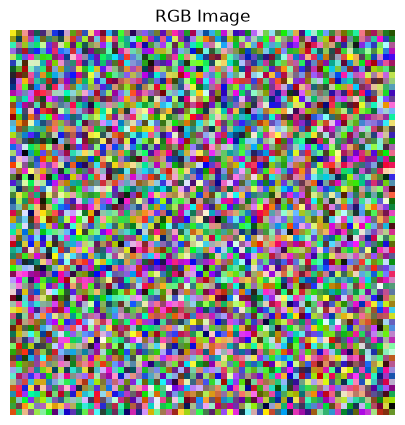

In [6]:
plt.figure(figsize=(5, 5))

plt.imshow(image)
plt.axis("off")
plt.title("RGB Image")

plt.show()

# Main Components of CNN

A typical CNN architecture looks like:

Input Image
↓
Convolution Layer
↓
ReLU Activation
↓
Pooling Layer
↓
Convolution Layer
↓
ReLU Activation
↓
Pooling Layer
↓
Flatten
↓
Dense Layer
↓
Output Layer

Each component has a different purpose.

## 1. Convolution Layer

The convolution layer is the main feature-extraction layer of a CNN.

It uses small filters (kernels) to scan across the image.

The filters learn useful patterns such as:

- Edges
- Lines
- Corners
- Textures
- Shapes

In TensorFlow/Keras, we can create a convolution layer using `Conv2D`.

In [7]:
conv_layer = tf.keras.layers.Conv2D(
    filters=32,
    kernel_size=(3, 3),
    activation="relu"
)

print(conv_layer)

<Conv2D name=conv2d, built=False>



---

### Markdown Cell 12

```markdown
## 2. Pooling Layer

Pooling reduces the spatial dimensions of feature maps.

One of the most common pooling techniques is **Max Pooling**.

For example:

8 × 8

can become:

4 × 4

using a 2 × 2 pooling window.

Pooling helps reduce:

- Computational cost
- Number of values
- Model complexity

while keeping important features.

In [8]:
pool_layer = tf.keras.layers.MaxPooling2D(
    pool_size=(2, 2)
)

print(pool_layer)

<MaxPooling2D name=max_pooling2d, built=True>


## 3. Flatten Layer

After convolution and pooling, the feature maps are converted into a one-dimensional vector.

For example:

8 × 8 × 32

becomes:

2048 values

This allows us to connect the extracted features to Dense layers.

In [9]:
flatten_layer = tf.keras.layers.Flatten()

print(flatten_layer)

<Flatten name=flatten, built=False>


## 4. Dense Layer

After feature extraction, Dense layers can be used for classification.

For example:

Dense(128, activation="relu")

means:

- 128 neurons
- ReLU activation

In [10]:
dense_layer = tf.keras.layers.Dense(
    128,
    activation="relu"
)

print(dense_layer)

<Dense name=dense, built=False>


## 5. Output Layer

The output layer depends on the problem.

### Binary Classification

For two classes:

```text
Cat / Dog
0 / 1

In [11]:
model = tf.keras.Sequential([
    
    tf.keras.layers.Input(shape=(64, 64, 3)),
    
    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu"
    ),
    
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),
    
    tf.keras.layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu"
    ),
    
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),
    
    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),
    
    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,281 (6.20 MB)

 Trainable params: 1,625,281 (6.20 MB)

 Non-trainable params: 0 (0.00 B)